In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from pmdarima import auto_arima


In [170]:
archivo = "../data/raw/sales.csv"
df = pd.read_csv(archivo)
df

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
...,...,...
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214


In [171]:
df.dtypes

date      object
sales    float64
dtype: object

In [172]:
df.duplicated().sum()

np.int64(0)

In [173]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

In [174]:
df.dtypes

date     datetime64[ns]
sales           float64
dtype: object

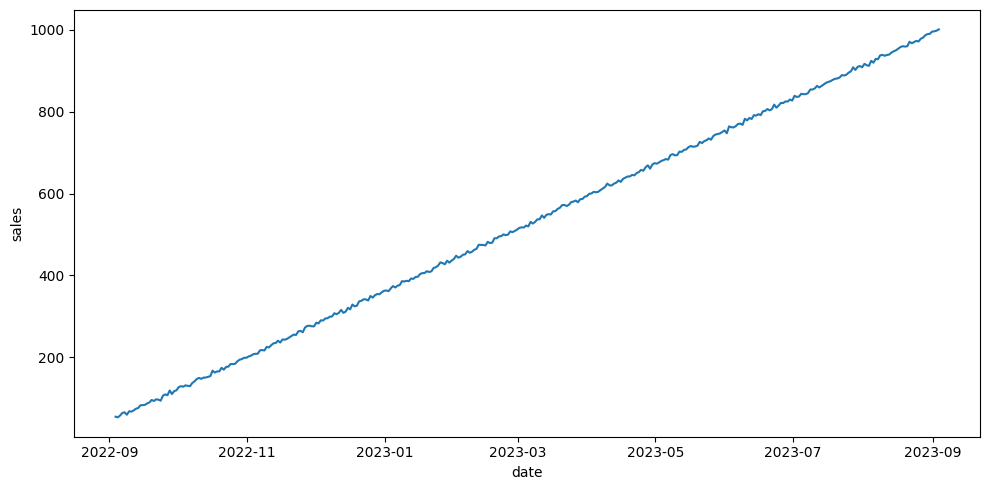

In [175]:
fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data=df, x="date", y="sales")

plt.tight_layout()

plt.show()

## ¿Cuál es la tendencia?

>Verificaremos el tipo de tendencia

In [176]:
decomposition = seasonal_decompose(df["sales"], period = 30)
decomposition

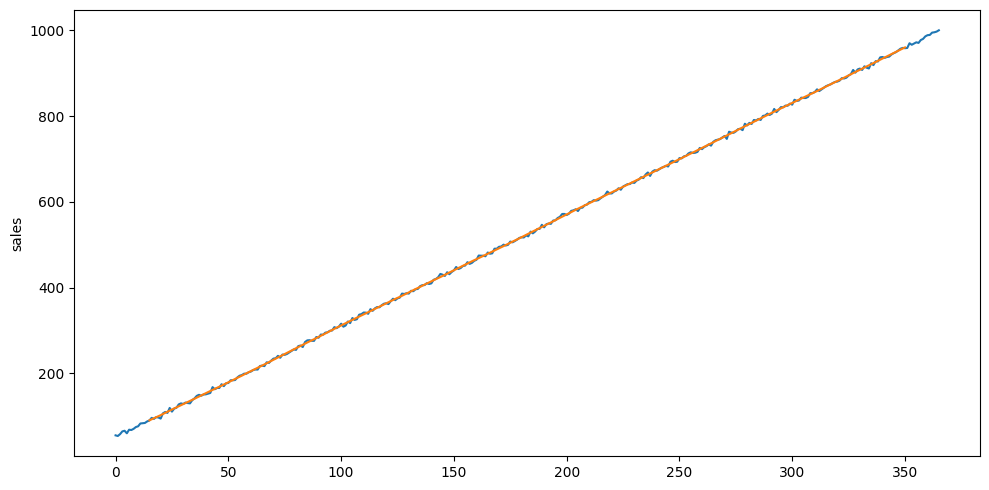

In [177]:
trend = decomposition.trend

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = df["sales"])
sns.lineplot(data = trend)

plt.tight_layout()

plt.show()

### Observaciones.

tenemos una clara tendencia alcista.

## ¿Cuál es el tensor de la serie temporal?

>para ello analizaremos los datos y definiremos que tiempo pasa entre uno y otro.

In [178]:
ts = df.set_index("date")["sales"].astype(float).to_numpy()   
tensor = ts.reshape(-1, 1)                                   
tensor.shape

(366, 1)

In [179]:
df["date"].min(), df["date"].max()

(Timestamp('2022-09-03 17:10:08.079328'),
 Timestamp('2023-09-03 17:10:08.079328'))

### Observaciones

>Viendo los datos tenemos 366 dias y las fechas min y max son coherentes a un dia por dato. 

## ¿Es estacionaria?

> Para eso analizaremos el grafico. 

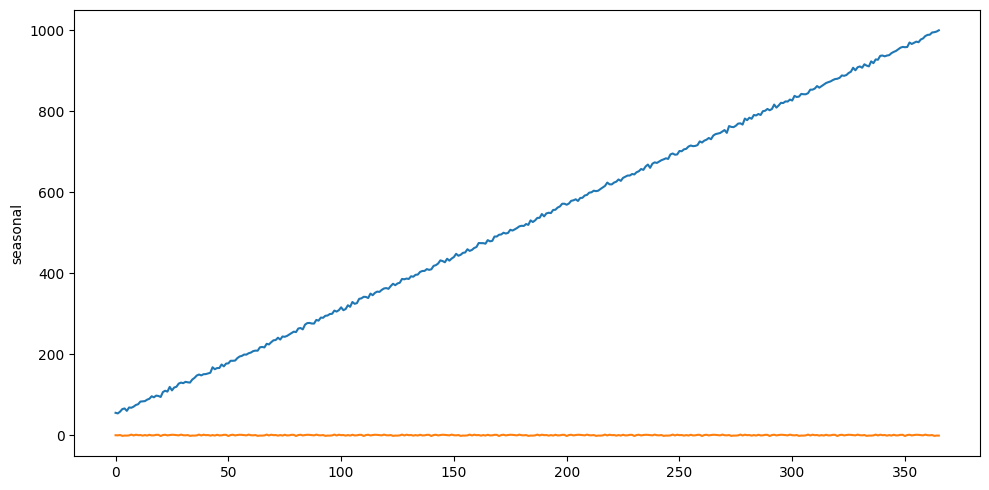

In [180]:
seasonal = decomposition.seasonal

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = seasonal)

plt.tight_layout()

plt.show()

In [181]:


def test_stationarity(timeseries):
    print("Resultados de la prueba de Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag = "AIC")
    dfoutput = pd.Series(dftest[0:4], index = ["Test Statistic", "p-value", "#Lags Used", "Number of Observations Used"])
    for key,value in dftest[4].items():
        dfoutput["Critical Value (%s)"%key] = value
    return dfoutput

test_stationarity(ts)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                   0.545414
p-value                          0.986190
#Lags Used                      13.000000
Number of Observations Used    352.000000
Critical Value (1%)             -3.449065
Critical Value (5%)             -2.869786
Critical Value (10%)            -2.571163
dtype: float64

## Observaciones

>Aquí podemos ver que el p-value es mayor a 0.05, esto significa que nuestra hipótesis nula será rechazada y tomaremos esta serie como no estacionaria.

## ¿Existe variabilidad o presencia de ruido?

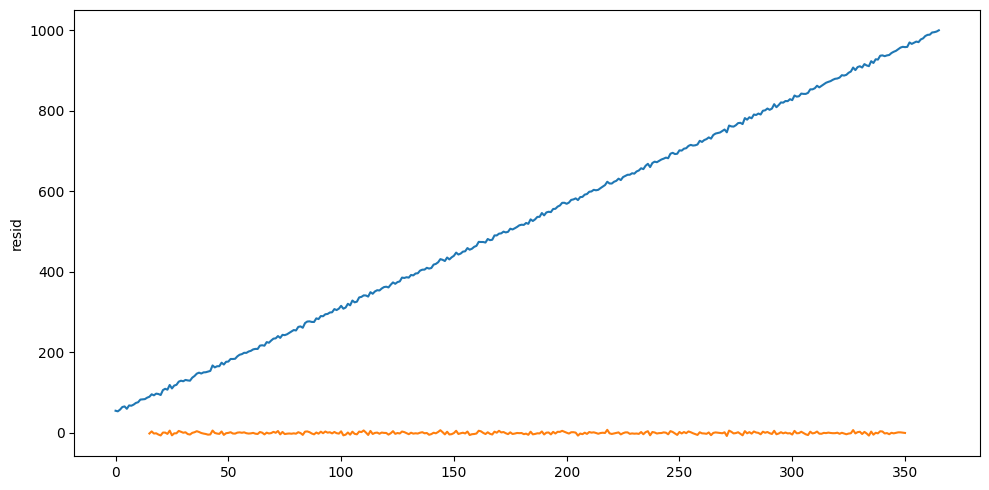

In [182]:
residual = decomposition.resid

fig, axis = plt.subplots(figsize = (10, 5))

sns.lineplot(data = ts)
sns.lineplot(data = residual)

plt.tight_layout()

plt.show()

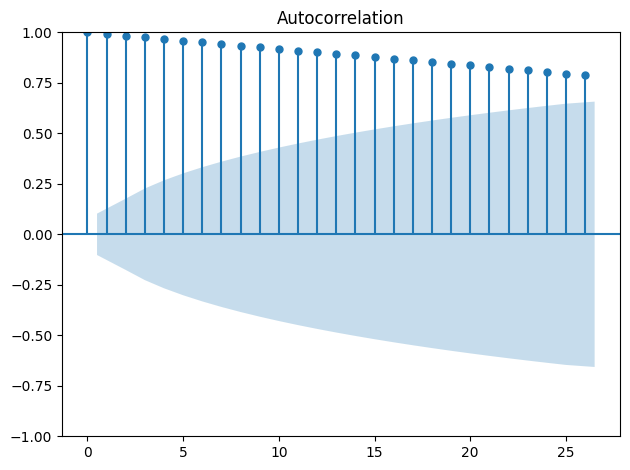

In [183]:
plot_acf(ts)

plt.tight_layout()

plt.show()

### Observaciones

> Podemos predecir hasta un periodo aproximado de 30 dias

## Modelo Arima

In [184]:
ts = df.set_index("date")["sales"].astype(float)
ts_stationary = ts.diff().dropna()

test_stationarity(ts_stationary)

Resultados de la prueba de Dickey-Fuller:


Test Statistic                -9.430263e+00
p-value                        5.212954e-16
#Lags Used                     1.200000e+01
Number of Observations Used    3.520000e+02
Critical Value (1%)           -3.449065e+00
Critical Value (5%)           -2.869786e+00
Critical Value (10%)          -2.571163e+00
dtype: float64

In [185]:
model = auto_arima(ts_stationary, seasonal=True, m=7, trace=True)
model_sin_diff = auto_arima(ts, seasonal=True, m=7, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.78 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=2096.542, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=1966.396, Time=0.17 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=inf, Time=0.40 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=2209.657, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=1970.972, Time=0.04 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=1968.120, Time=0.33 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=1968.220, Time=0.24 sec
 ARIMA(1,0,0)(0,0,1)[7] intercept   : AIC=1966.919, Time=0.09 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=1965.376, Time=0.75 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=1965.211, Time=0.89 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=1963.937, Time=0.61 sec
 ARIMA(1,0,0)(0,0,2)[7] intercept   : AIC=1967.822, Time=0.27 sec
 ARIMA(0,0,0)(1,0,2)[7] intercept   : AIC=2094.918, Time=0.72 sec
 ARIMA(2,0,0)(1,0,2)[7] intercept   : AIC=1

In [186]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                       SARIMAX Results                                        
==============================================================================================
Dep. Variable:                                      y   No. Observations:                  365
Model:             SARIMAX(2, 0, 1)x(1, 0, [1, 2], 7)   Log Likelihood                -910.863
Date:                                Fri, 05 Dec 2025   AIC                           1837.726
Time:                                        12:10:16   BIC                           1868.925
Sample:                                    09-04-2022   HQIC                          1850.125
                                         - 09-03-2023                                         
Covariance Type:                                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.1892      0.477     10.869      0.000       4.253       6.125
ar.L1         -0.0774      0.054     -1.436      0.151      -0.183       0.028
ar.L2          0.0539      0.059      0.918      0.359      -0.061       0.169
ma.L1         -0.9773      0.018    -55.002      0.000      -1.012      -0.942
ar.S.L7       -0.9504      0.075    -12.606      0.000      -1.098      -0.803
ma.S.L7        1.1090      0.092     12.025      0.000       0.928       1.290
ma.S.L14       0.1809      0.054      3.358      0.001       0.075       0.286
sigma2         8.6913      0.697     12.474      0.000       7.326      10.057
===================================================================================
Ljung-Box (L1) (Q):                   0.09   Jarque-Bera (JB):                 0.17
Prob(Q):                              0.77   Prob(JB):                         0.92
Heteroskedasticity (H):               0.87   Skew:                             0.04
Prob(H) (two-sided):                  0.46   Kurtosis:                         2.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [187]:
model_sin_diff.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                  366
Model:             SARIMAX(4, 1, 1)x(0, 0, 1, 7)   Log Likelihood                -912.372
Date:                           Fri, 05 Dec 2025   AIC                           1840.744
Time:                                   12:10:17   BIC                           1871.943
Sample:                               09-03-2022   HQIC                          1853.143
                                    - 09-03-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.8853      0.378      7.634      0.000       2.145       3.626
ar.L1         -0.0805      0.054     -1.500      0.134      -0.186       0.025
ar.L2          0.0168      0.063      0.269      0.788      -0.106       0.139
ar.L3          0.0242      0.058      0.414      0.679      -0.090       0.139
ar.L4         -0.0713      0.053     -1.351      0.177      -0.175       0.032
ma.L1         -0.9393      0.026    -36.334      0.000      -0.990      -0.889
ma.S.L7        0.1039      0.053      1.944      0.052      -0.001       0.209
sigma2         8.4131      0.658     12.789      0.000       7.124       9.702
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.95
Prob(Q):                              0.95   Prob(JB):                         0.62
Heteroskedasticity (H):               0.91   Skew:                             0.07
Prob(H) (two-sided):                  0.59   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [188]:
forecast = model.predict(30)
forecast_sin_diff = model_sin_diff.predict(30)
forecast

2023-09-04 17:10:08.079328    2.082317
2023-09-05 17:10:08.079328    3.051095
2023-09-06 17:10:08.079328    1.940035
2023-09-07 17:10:08.079328    3.235950
2023-09-08 17:10:08.079328    1.729522
2023-09-09 17:10:08.079328    3.064951
2023-09-10 17:10:08.079328    2.353270
2023-09-11 17:10:08.079328    2.286203
2023-09-12 17:10:08.079328    2.548106
2023-09-13 17:10:08.079328    2.733508
2023-09-14 17:10:08.079328    2.545574
2023-09-15 17:10:08.079328    3.101895
2023-09-16 17:10:08.079328    1.950083
2023-09-17 17:10:08.079328    2.850766
2023-09-18 17:10:08.079328    2.708145
2023-09-19 17:10:08.079328    2.663735
2023-09-20 17:10:08.079328    2.460580
2023-09-21 17:10:08.079328    2.652293
2023-09-22 17:10:08.079328    2.121115
2023-09-23 17:10:08.079328    3.216659
2023-09-24 17:10:08.079328    2.360475
2023-09-25 17:10:08.079328    2.496082
2023-09-26 17:10:08.079328    2.538272
2023-09-27 17:10:08.079328    2.731349
2023-09-28 17:10:08.079328    2.549150
2023-09-29 17:10:08.07932

In [189]:
forecast_sin_diff

2023-09-04 17:10:08.079328    1002.221618
2023-09-05 17:10:08.079328    1005.067987
2023-09-06 17:10:08.079328    1007.539800
2023-09-07 17:10:08.079328    1010.356685
2023-09-08 17:10:08.079328    1012.902669
2023-09-09 17:10:08.079328    1015.324514
2023-09-10 17:10:08.079328    1017.970064
2023-09-11 17:10:08.079328    1020.459244
2023-09-12 17:10:08.079328    1023.065733
2023-09-13 17:10:08.079328    1025.674424
2023-09-14 17:10:08.079328    1028.265166
2023-09-15 17:10:08.079328    1030.871385
2023-09-16 17:10:08.079328    1033.467741
2023-09-17 17:10:08.079328    1036.064559
2023-09-18 17:10:08.079328    1038.662830
2023-09-19 17:10:08.079328    1041.259648
2023-09-20 17:10:08.079328    1043.857323
2023-09-21 17:10:08.079328    1046.454906
2023-09-22 17:10:08.079328    1049.052372
2023-09-23 17:10:08.079328    1051.649971
2023-09-24 17:10:08.079328    1054.247493
2023-09-25 17:10:08.079328    1056.845028
2023-09-26 17:10:08.079328    1059.442572
2023-09-27 17:10:08.079328    1062

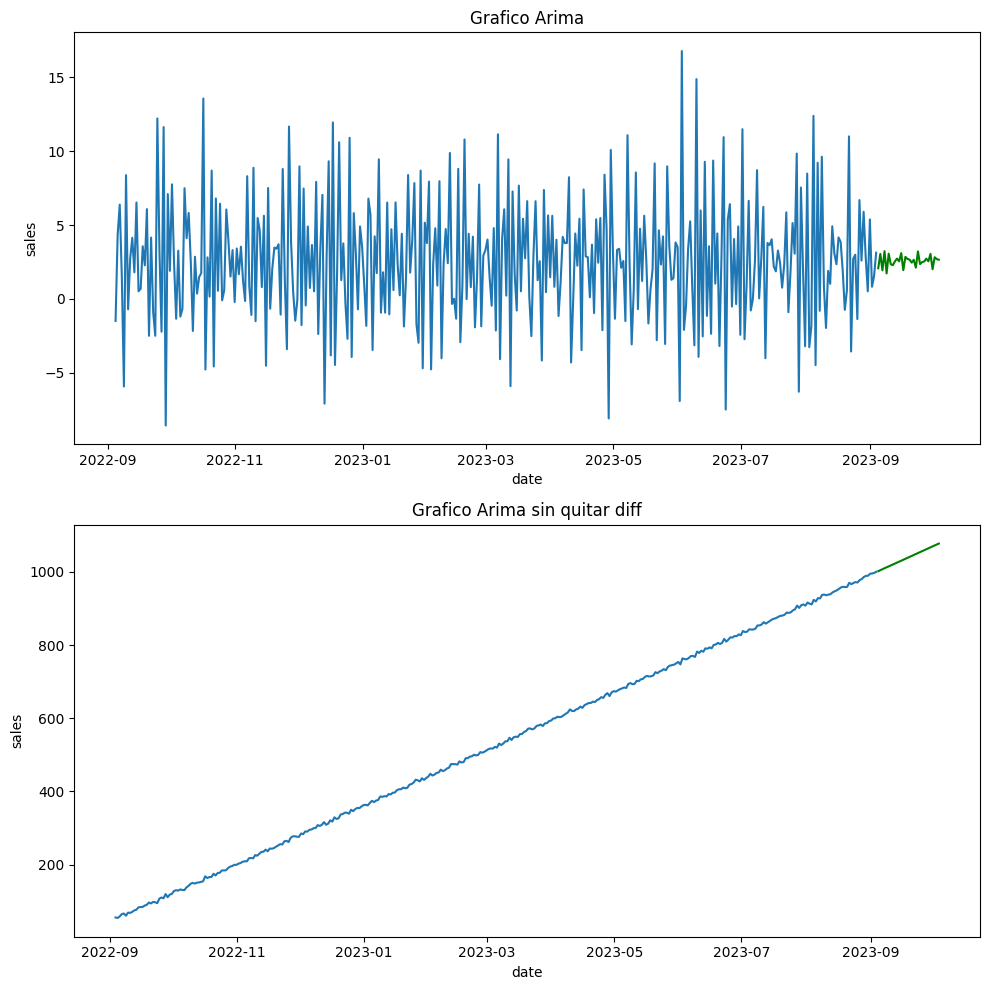

In [195]:
fig, axis = plt.subplots(2, 1, figsize=(10, 10))

sns.lineplot(ax=axis[0], data=ts_stationary).set(title="Grafico Arima")
sns.lineplot(ax=axis[0], data=forecast, c="green")
sns.lineplot(ax=axis[1], data=ts).set(title="Grafico Arima sin quitar diff")
sns.lineplot(ax=axis[1], data=forecast_sin_diff, c="green")

plt.tight_layout()

plt.show()

## Conclusiones

> Podemos ver que gracias al Arima podemos predecir los graficos a futuro.
>
>En el primer grafico aunque no pareciera una constante clara podemos visualizar que los valores de `Sales` estan entre -5 y 15 aproximadamente. Se crea una prediccion de 10 dias que parece no seguir un patrón claro.
>
>En el segundo gráfico los visualizamos sin Diff y notamos que sigue el patron de conducta que llevaba anteriormente.